<a href="https://colab.research.google.com/github/halimAhtasham/DeepLearning/blob/main/09_Final_Test_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 9: Final Test Evaluation**

Evaluate the selected tuned KNN model on the previously untouched test
dataset.

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report
- ROC Curve

The test dataset was not used during preprocessing decisions,
cross-validation, hyperparameter tuning, or model selection.

# **Library Import**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Project Path

In [2]:
PROJECT_PATH = "/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction"

DATASET_PATH = PROJECT_PATH + "/Dataset"
RESULT_PATH = PROJECT_PATH + "/Results"
MODEL_PATH = PROJECT_PATH + "/Models"

# **Load and Clean the Dataset**

In [3]:
df = pd.read_csv(DATASET_PATH + "/heart.csv")

df_clean = df.drop_duplicates().copy()

print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)

Original dataset: (1025, 14)
Cleaned dataset: (302, 14)


# **Separate X and y**

In [4]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]
print(X.shape)
print(y.shape)

(302, 13)
(302,)


# **Train / Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("Training Samples ", len(X_train))
print("Testing Samples",len(X_test))

Training Samples  241
Testing Samples 61


# **Load the Tuned KNN**

In [12]:
final_model = joblib.load(
    MODEL_PATH + "/tuned_knn.pkl"
)

In [13]:
print(final_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=21, p=1))])


# **Train Final Model**

In [14]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=21, p=1))])

# **Prediction**

In [15]:
y_pred = final_model.predict(X_test)

In [16]:
y_prob = final_model.predict_proba(X_test)[:, 1]

## ***Accuracy***

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy: ", accuracy)

Test Accuracy:  0.819672131147541


## ***Precision***

In [18]:
precision = precision_score(y_test, y_pred)
print("Test Precision: ", precision)

Test Precision:  0.8235294117647058


## ***F1 Score***

In [19]:
f1 = f1_score(y_test, y_pred)
print("Test F1 Score: ", f1)

Test F1 Score:  0.835820895522388


## ***Recall***

In [20]:
recall = recall_score(y_test, y_pred)
print("Test Recall: ", recall)

Test Recall:  0.8484848484848485


## ***ROC_AUC***

In [21]:
roc_auc = roc_auc_score(y_test, y_prob)
print("Test ROC AUC: ", roc_auc)

Test ROC AUC:  0.8944805194805195


In [24]:
print("FINAL TEST RESULTS - TUNED KNN\n")


print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL TEST RESULTS - TUNED KNN

Accuracy : 0.8197
Precision: 0.8235
Recall   : 0.8485
F1-score : 0.8358
ROC-AUC  : 0.8945


# **Final Result Data Frame**

In [25]:
final_results = pd.DataFrame({
    "Model": ["Tuned KNN"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-Score": [f1],
    "ROC-AUC": [roc_auc]
})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned KNN,0.8197,0.8235,0.8485,0.8358,0.8945


# **Classification Report**

In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.81      0.79      0.80        28
   Heart Disease       0.82      0.85      0.84        33

        accuracy                           0.82        61
       macro avg       0.82      0.82      0.82        61
    weighted avg       0.82      0.82      0.82        61



# **Confusion Matrix**

In [27]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[22  6]
 [ 5 28]]


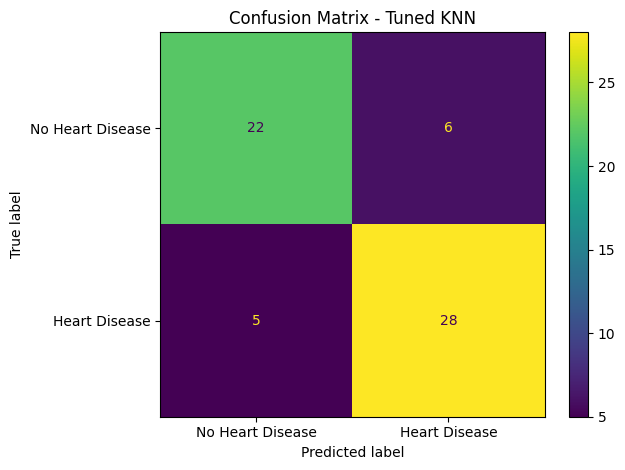

In [28]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

disp.plot()

plt.title("Confusion Matrix - Tuned KNN")
plt.tight_layout()
plt.show()

# **ROC Curve**

In [29]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

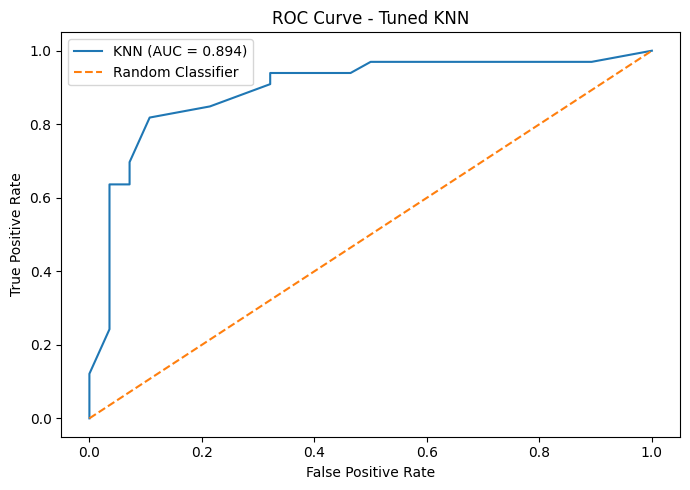

In [30]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned KNN")
plt.legend()

plt.tight_layout()
plt.show()

## **Compare Cross Validation VS Final Test**

In [31]:
cv_vs_test = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],

    "Cross-Validation": [
        0.8545,
        0.8328,
        0.9308,
        0.8753,
        0.9254
    ],

    "Final Test": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

cv_vs_test.round(4)

,Metric,Cross-Validation,Final Test
0,Accuracy,0.8545,0.8197
1,Precision,0.8328,0.8235
2,Recall,0.9308,0.8485
3,F1-Score,0.8753,0.8358
4,ROC-AUC,0.9254,0.8945


In [32]:
cv_vs_test["Difference"] = (
    cv_vs_test["Final Test"]
    - cv_vs_test["Cross-Validation"]
)

cv_vs_test.round(4)

,Metric,Cross-Validation,Final Test,Difference
0,Accuracy,0.8545,0.8197,-0.0348
1,Precision,0.8328,0.8235,-0.0093
2,Recall,0.9308,0.8485,-0.0823
3,F1-Score,0.8753,0.8358,-0.0395
4,ROC-AUC,0.9254,0.8945,-0.0309


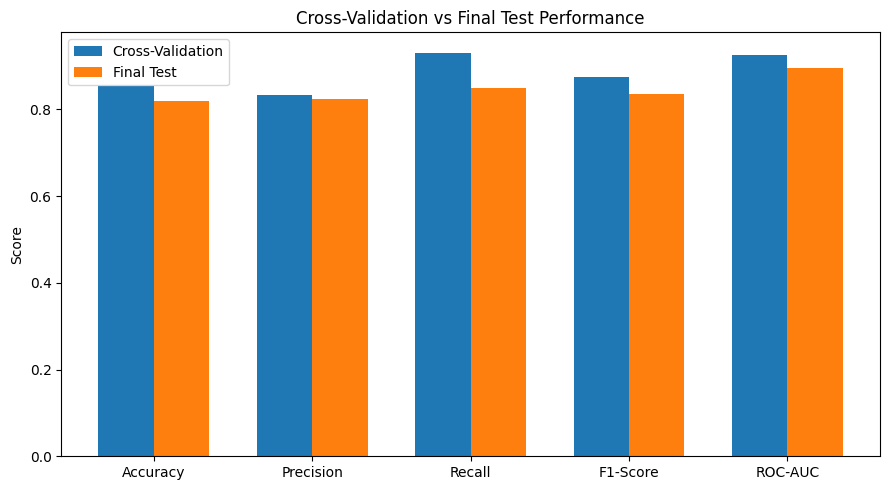

In [33]:
x = np.arange(len(cv_vs_test["Metric"]))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    cv_vs_test["Cross-Validation"],
    width,
    label="Cross-Validation"
)

plt.bar(
    x + width/2,
    cv_vs_test["Final Test"],
    width,
    label="Final Test"
)

plt.xticks(
    x,
    cv_vs_test["Metric"]
)

plt.ylabel("Score")
plt.title("Cross-Validation vs Final Test Performance")
plt.legend()

plt.tight_layout()
plt.show()

# **Save Final Results**

In [34]:
final_results.to_csv(
    RESULT_PATH + "/final_test_results.csv",
    index=False
)

In [35]:
cv_vs_test.to_csv(
    RESULT_PATH + "/cv_vs_test_comparison.csv",
    index=False
)

In [36]:
joblib.dump(
    final_model,
    MODEL_PATH + "/final_heart_disease_model.pkl"
)

['/content/drive/MyDrive/Machine Learning/Projects/Heart Disease Prediction/Models/final_heart_disease_model.pkl']